# Pertemuan 7 - Pengantar Machine Learning: Regresi Linear

Nama: Widya Anggara  
NIM: 230401020091  
Kelas: IF401

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='Set2')

# Generate Dataset Sintesis

In [2]:
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # 0=SMA, 1=D3, 2=S1
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


# EDA

In [3]:
print('Shape:', df.shape)

print('\nTipe Data:')
print(df.dtypes)

print('\nStatistik Deskriptif:')
print(df.describe().round(2))

print('\nJumlah Data per Kota:')
print(df['kota'].value_counts())

print('\nRata-rata Gaji per Kota:')
print(df.groupby('kota')['gaji'].mean().round(2))

Shape: (300, 4)

Tipe Data:
pengalaman    float64
edu             int64
kota           object
gaji          float64
dtype: object

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22

Jumlah Data per Kota:
kota
Surabaya    106
Jakarta      97
Bandung      97
Name: count, dtype: int64

Rata-rata Gaji per Kota:
kota
Bandung     26.78
Jakarta     30.87
Surabaya    24.79
Name: gaji, dtype: float64


# Visualisasi Pengalaman vs Gaji

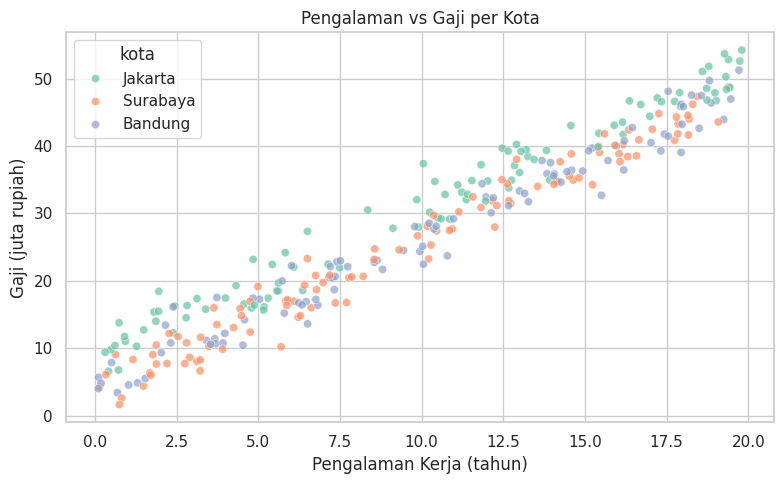

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    alpha=0.7,
    ax=ax
)

ax.set_title('Pengalaman vs Gaji per Kota')
ax.set_xlabel('Pengalaman Kerja (tahun)')
ax.set_ylabel('Gaji (juta rupiah)')

plt.tight_layout()
plt.show()

# Preprocessing

In [5]:
df_encoded = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print('Kolom setelah encoding:')
print(df_encoded.columns.tolist())

df_encoded.head()

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [6]:
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

print('Fitur:')
print(X.head())

print('\nTarget:')
print(y.head())

Fitur:
   pengalaman  edu  kota_Jakarta  kota_Surabaya
0    7.490802    0             1              0
1   19.014286    1             1              0
2   14.639879    2             0              1
3   11.973170    2             0              0
4    3.120373    2             1              0

Target:
0    21.953247
1    46.721665
2    34.952649
3    32.437143
4    17.384265
Name: gaji, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')

Train: 240 baris
Test : 60 baris


In [8]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Mean scaler:')
print(scaler.mean_.round(3))

print('\nStandard deviation scaler:')
print(scaler.scale_.round(3))

Mean scaler:
[9.871 0.908 0.35  0.35 ]

Standard deviation scaler:
[5.934 0.837 0.477 0.477]


# Train Model

In [9]:
model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

coef_df

β₀ (intercept): 27.514


,Fitur,Koefisien
0,pengalaman,13.042
2,kota_Jakarta,1.837
1,edu,1.188
3,kota_Surabaya,-0.292


# Prediksi dan Evaluasi Model

In [10]:
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'MSE  = {mse:.3f}')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
MSE  = 4.507
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


# Visualisasi

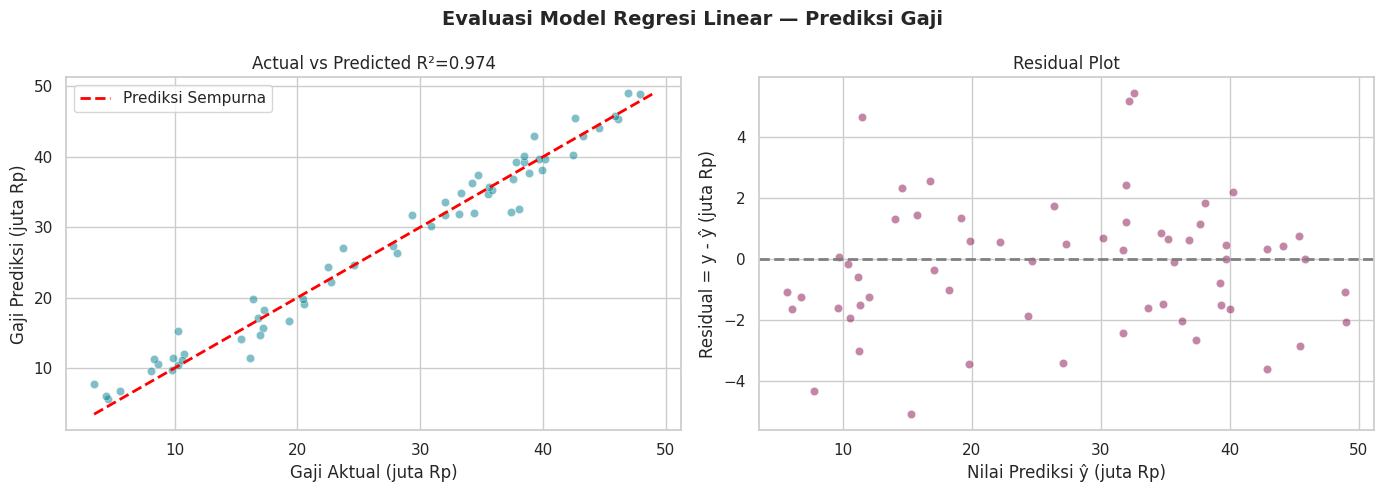

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--',
    lw=2
)

axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y - ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

Pada grafik Actual vs Predicted, titik yang semakin dekat dengan garis merah menunjukkan prediksi yang semakin akurat. Jika banyak titik berada di sekitar garis tersebut, maka model memiliki performa prediksi yang baik.

Pada residual plot, titik-titik terlihat tersebar di sekitar garis 0. Hal ini menunjukkan bahwa error prediksi relatif acak dan tidak membentuk pola tertentu. Jika residual membentuk pola seperti kurva atau corong, maka ada kemungkinan hubungan data tidak sepenuhnya linear.

## Kesimpulan

Pada praktikum Pertemuan 7 ini, saya mempelajari konsep dasar Machine Learning khususnya Regresi Linear. Regresi Linear digunakan untuk memprediksi nilai kontinu, dalam praktikum ini yaitu prediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja.

Tahapan yang dilakukan meliputi pembuatan dataset sintetis, eksplorasi data, encoding data kategorikal, train-test split, feature scaling, pelatihan model Linear Regression, evaluasi model menggunakan MAE, RMSE, dan R², serta visualisasi hasil prediksi menggunakan Actual vs Predicted dan Residual Plot.

Berdasarkan hasil model, pengalaman kerja memiliki pengaruh kuat terhadap gaji. Model Regresi Linear mampu menangkap pola hubungan linear antara fitur dan target dengan cukup baik. Nilai MAE dan RMSE menunjukkan rata-rata kesalahan prediksi dalam satuan juta rupiah, sedangkan nilai R² menunjukkan seberapa besar variasi gaji yang berhasil dijelaskan oleh model.